# DSA4212 Next Character Prediction



## Imports

Below are all the imports we used for this assignment

In [1]:
import jax
import flax
import os
import numpy as np
import jax
import jax.numpy as jnp
import optax
import flax.linen as nn
from jax import random
import optuna
from dataclasses import dataclass
import functools
import json
import pickle
import optuna.visualization as vis
import time
import matplotlib.pyplot as plt


Opening the dataset to find out the number of characters for the train and test set

In [19]:
with open("data/text8_train.txt", "r") as f:
    train_text = f.read()
with open("data/text8_test.txt", "r") as f:
    test_text = f.read()

print(f"Length of training text: {len(train_text):_} characters")
print(f"Length of test text: {len(test_text):_} characters")

Length of training text: 90_000_000 characters
Length of test text: 5_000_000 characters


Encoding the characters in the dataset so they can be fed into the LSTM

In [3]:
char_set = list("abcdefghijklmnopqrstuvwxyz ")
char_to_int = {ch:i for i,ch in enumerate(char_set)}
int_to_char = {i:ch for ch,i in char_to_int.items()}

def encode(s):
    """Encode string to array of integers"""
    ids = [char_to_int[c] for c in s]
    return np.array(ids, dtype=np.uint8)

In [4]:
train_text_int = encode(train_text)
test_text_int = encode(test_text)

Further splitting the train set to train and val as we are performing hyperparameter tuning and we do not want any data leakage to occur

In [ ]:
split_idx = int(len(train_text_int) * 0.9) 
train_tokens = train_text_int[:split_idx]
val_tokens   = train_text_int[split_idx:]

Creating a simple LSTM model

In [6]:
class LSTM(nn.Module):
    hidden_size: int
    vocab_size: int
    num_layers: int = 2
    dropout_rate: float = 0.0

    @nn.compact
    def __call__(self, x, train: bool = True):
        x = nn.Embed(num_embeddings=self.vocab_size, features=self.hidden_size)(x)
        x = nn.Dropout(rate=self.dropout_rate, deterministic=not train)(x)

        for layer_idx in range(self.num_layers):
            ScanLSTM = nn.scan(
                nn.OptimizedLSTMCell,
                variable_broadcast="params",
                split_rngs={"params": False},
                in_axes=1,
                out_axes=1
            )
            lstm = ScanLSTM(self.hidden_size, name=f'lstm_layer_{layer_idx}')

            input_shape = x[:, 0].shape
            carry = lstm.initialize_carry(random.key(layer_idx), input_shape)

            residual = x
            carry, x = lstm(carry, x)

            if layer_idx > 0:
                x = x + residual

            x = nn.LayerNorm()(x)

            if layer_idx < self.num_layers - 1:
                x = nn.Dropout(rate=self.dropout_rate, deterministic=not train)(x)

        x = nn.Dense(self.hidden_size * 2)(x)
        x = nn.gelu(x)
        x = nn.Dropout(rate=self.dropout_rate, deterministic=not train)(x)
        x = nn.Dense(self.vocab_size)(x)
        return x

Creating the config to store the tuned hyperparameters

In [11]:
@dataclass(frozen=True)
class Config:
    vocab_size: int = 27
    block_size: int = 128
    hidden_size: int = 256
    dropout_rate: float = 0.1
    num_layers: int = 2
    lr: float = 1e-3

Creating functions such as the loss function and evaluation function to use later for model training and hyperparameter tuning

In [ ]:
def init_params(rng, cfg):
    model = LSTM(hidden_size=cfg.hidden_size, vocab_size=cfg.vocab_size, num_layers=cfg.num_layers, dropout_rate=cfg.dropout_rate)
    dummy_input = jnp.ones((1, cfg.block_size), dtype=jnp.int32)
    params = model.init(rng, dummy_input, train=False)
    return params

def loss_fn(params, batch, cfg, rng, train=True):
    """Cross-entropy loss for language modeling"""
    model = LSTM(
        hidden_size=cfg.hidden_size,
        vocab_size=cfg.vocab_size,
        num_layers=cfg.num_layers,
        dropout_rate=cfg.dropout_rate
    )

    if train:
        logits = model.apply(params, batch['input'], train=train, rngs={'dropout': rng})
    else:
        logits = model.apply(params, batch['input'], train=train)

    logits_flat = logits.reshape(-1, cfg.vocab_size)
    targets_flat = batch['target'].reshape(-1)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits_flat, targets_flat
    ).mean()
    return loss

def make_batch_from_array(arr, batch_size, block_size, rng):
    N = len(arr) - block_size - 1
    starts = rng.randint(0, N, size=(batch_size,))
    inputs = np.stack([arr[s:s+block_size] for s in starts])
    targets = np.stack([arr[s+1:s+1+block_size] for s in starts])
    return {'input': jnp.array(inputs, dtype=jnp.int32), 'target': jnp.array(targets, dtype=jnp.int32)}


def eval_loss(params, val_tokens, cfg_to_use, batch_size=None):
    rng_eval = np.random.RandomState(0)
    losses = []
    for _ in range(50):
        batch = make_batch_from_array(val_tokens, batch_size,
                                      cfg_to_use.block_size,
                                      rng_eval
                                    )
        l = float(loss_fn(params, batch, cfg_to_use, rng=None, train=False))
        losses.append(l)
    return np.mean(losses)

rng_np = np.random.RandomState(123)

Creating the objective function for Bayesian Optimization

In [10]:
def objective(trial):

    hidden_size = trial.suggest_categorical("hidden_size", [64, 128, 256, 512])
    num_layers = trial.suggest_int("num_layers", 1, 4)
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])
    block_size = trial.suggest_categorical("block_size", [64, 128, 256])
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)

    cfg = Config(
        vocab_size=27,
        block_size=block_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout_rate=dropout_rate,
        lr=lr
    )

    rng = jax.random.PRNGKey(0)
    params = init_params(rng, cfg)
    scaled_lr = lr * (batch_size / 32)
    optimizer = optax.adamw(scaled_lr)
    opt_state = optimizer.init(params)
    dropout_rng = jax.random.PRNGKey(0)
    @functools.partial(jax.jit, static_argnums=(4,))
    def train_step_trial(params, opt_state, batch, dropout_rng, cfg):
        def loss_fn_inner(params):
            return loss_fn(params, batch, cfg, dropout_rng, train=True)

        grads = jax.grad(loss_fn_inner)(params)
        updates, opt_state = optimizer.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        return params, opt_state

    rng_np = np.random.RandomState(123)
    for step in range(500):
        batch = make_batch_from_array(train_tokens, batch_size=batch_size, block_size=cfg.block_size, rng=rng_np)
        dropout_rng, step_rng = jax.random.split(dropout_rng)
        params, opt_state = train_step_trial(params, opt_state, batch, step_rng, cfg)

    val_l = eval_loss(params, val_tokens, cfg, batch_size=batch_size)
    return float(val_l)


Running the Bayesian Optimization

In [ ]:
study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=100)
)

# Run optimization
study.optimize(objective, n_trials=100)

best_params = study.best_params

with open("LSTM_utils/LSTM_best_hparams.json", "w") as f:
    json.dump(best_params, f, indent=4)

fig = vis.plot_optimization_history(study)
fig.write_image("LSTM_BO_pics/optimization_history.png")

fig = vis.plot_param_importances(study)
fig.write_image("LSTM_BO_pics/hyperparameter_importance.png")

[I 2025-11-18 05:50:39,700] A new study created in memory with name: no-name-eb78f3bf-17b6-4be5-a235-d1f025e284c6
[I 2025-11-18 05:52:59,943] Trial 0 finished with value: 1.9962559199333192 and parameters: {'hidden_size': 512, 'num_layers': 3, 'lr': 8.483821180432347e-05, 'batch_size': 32, 'block_size': 128, 'dropout_rate': 0.2758800780610055}. Best is trial 0 with value: 1.9962559199333192.
[I 2025-11-18 05:54:25,206] Trial 1 finished with value: 1.8008531284332276 and parameters: {'hidden_size': 64, 'num_layers': 4, 'lr': 0.0003337867677798087, 'batch_size': 64, 'block_size': 128, 'dropout_rate': 0.041323321459937834}. Best is trial 1 with value: 1.8008531284332276.
[I 2025-11-18 05:55:53,177] Trial 2 finished with value: 2.3666735553741454 and parameters: {'hidden_size': 256, 'num_layers': 4, 'lr': 0.0002924318385692405, 'batch_size': 16, 'block_size': 64, 'dropout_rate': 0.3820481472818478}. Best is trial 1 with value: 1.8008531284332276.
[I 2025-11-18 05:57:37,106] Trial 3 finishe

Loading best hyperparameters

In [17]:
with open("LSTM_utils/LSTM_best_hparams.json", "r") as f:
    best_params = json.load(f)

print(best_params)
best_cfg = Config(
    vocab_size=27,
    block_size=best_params["block_size"],
    hidden_size=best_params["hidden_size"],
    dropout_rate=best_params["dropout_rate"],
    num_layers=best_params["num_layers"],
    lr=best_params["lr"]
)
batch_size = best_params['batch_size']

{'hidden_size': 512, 'num_layers': 4, 'lr': 0.0007228785934213479, 'batch_size': 64, 'block_size': 128, 'dropout_rate': 0.027827171269309104}


Creating scheduler and optimizer

In [13]:
rng = jax.random.PRNGKey(0)
num_epochs = 10
steps_per_epoch = len(train_tokens) // (batch_size * best_cfg.block_size)
total_steps = num_epochs * steps_per_epoch

warmup_steps = min(1000, total_steps // 10)
scheduler = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=best_cfg.lr * (batch_size / 32),
    warmup_steps=warmup_steps,
    decay_steps=total_steps - warmup_steps,
    end_value=1e-5
)
params = init_params(rng, best_cfg)
optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adamw(scheduler)
)
dropout_rng = jax.random.PRNGKey(0)

opt_state = optimizer.init(params)

Total number of steps per epoch

In [15]:
print(total_steps)

87890


Creating train step

In [14]:
@functools.partial(jax.jit, static_argnums=(4,))
def train_step(params, opt_state, batch, dropout_rng, cfg):
    """Single training step"""
    def loss_fn_inner(params):
        return loss_fn(params, batch, cfg, dropout_rng, train=True)

    loss_value, grads = jax.value_and_grad(loss_fn_inner)(params)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss_value

Training the LSTM model

In [ ]:
patience = 3
min_delta = 0.0001

train_losses = []
val_losses = []
best_val_loss = float('inf')
best_params_checkpoint = None
epochs_without_improvement = 0

rng_np_train = np.random.RandomState(123)


print("Starting training...")
print(f"Early stopping: patience={patience}, min_delta={min_delta}")
start_time = time.time()

for epoch in range(num_epochs):
    epoch_start = time.time()
    epoch_losses = []

    for step in range(steps_per_epoch):
        batch = make_batch_from_array(
            train_tokens,
            batch_size=batch_size,
            block_size=best_cfg.block_size,
            rng=rng_np_train
        )

        dropout_rng, step_rng = jax.random.split(dropout_rng)

        params, opt_state, loss_value = train_step(
            params, opt_state, batch, step_rng, best_cfg
        )

        epoch_losses.append(float(loss_value))

        # Log every 100 steps
        if step % 100 == 0:
          print(f"Epoch {epoch+1}/{num_epochs}, Step {step}/{steps_per_epoch}, "f"Loss: {loss_value:.4f}")

    avg_train_loss = np.mean(epoch_losses)
    train_losses.append(avg_train_loss)

    val_loss = eval_loss(params, val_tokens, best_cfg, batch_size=batch_size)
    val_losses.append(val_loss)

    epoch_time = time.time() - epoch_start

    print(f"\n{'='*60}")
    print(f"Epoch {epoch+1}/{num_epochs} Complete")
    print(f"Average Train Loss: {avg_train_loss:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Time: {epoch_time:.2f}s")

    # Check for improvement
    if val_loss < (best_val_loss - min_delta):
        best_val_loss = val_loss
        best_params_checkpoint = jax.tree.map(lambda x: x.copy(), params)
        epochs_without_improvement = 0

        # Save best model
        checkpoint = {
            'params': best_params_checkpoint,
            'config': best_cfg,
            'epoch': epoch + 1,
            'val_loss': val_loss,
            'train_loss': avg_train_loss
        }
        with open("LSTM_utils/LSTM_ckpt_best.pkl", "wb") as f:
            pickle.dump(checkpoint, f)

        print(f"New best validation loss: {val_loss:.4f} - Model saved!")
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epoch(s)")

    print(f"{'='*60}\n")

    # Early stopping check
    if epochs_without_improvement >= patience:
        print(f"Early stopping triggered! No improvement for {patience} epochs.")
        print(f"Best validation loss: {best_val_loss:.4f}")
        break

total_time = time.time() - start_time
print(f"\nTraining completed in {total_time/60:.2f} minutes")
print(f"Total epochs trained: {epoch + 1}/{num_epochs}")
print(f"Best validation loss: {best_val_loss:.4f}")


history = {
    'train_losses': [float(x) for x in train_losses],
    'val_losses': [float(x) for x in val_losses],
    'best_val_loss': float(best_val_loss),
    'total_epochs': int(epoch + 1),
    'early_stopped': bool(epochs_without_improvement >= patience),
    'config': {
        'vocab_size': best_cfg.vocab_size,
        'block_size': best_cfg.block_size,
        'hidden_size': best_cfg.hidden_size,
        'num_layers': best_cfg.num_layers,
        'dropout_rate': best_cfg.dropout_rate,
        'lr': best_cfg.lr,
        'batch_size': batch_size
    }
}
with open("LSTM_utils/LSTM_training_history.json", "w") as f:
    json.dump(history, f, indent=2)

print("Training history saved as JSON!")

Starting training...
Early stopping: patience=3, min_delta=0.0001
Epoch 1/10, Step 0/8789, Loss: 3.5404
Epoch 1/10, Step 100/8789, Loss: 2.0241
Epoch 1/10, Step 200/8789, Loss: 1.7878
Epoch 1/10, Step 300/8789, Loss: 1.5932
Epoch 1/10, Step 400/8789, Loss: 1.5033
Epoch 1/10, Step 500/8789, Loss: 1.4718
Epoch 1/10, Step 600/8789, Loss: 1.3974
Epoch 1/10, Step 700/8789, Loss: 1.4287
Epoch 1/10, Step 800/8789, Loss: 1.4310
Epoch 1/10, Step 900/8789, Loss: 1.4081
Epoch 1/10, Step 1000/8789, Loss: 1.4054
Epoch 1/10, Step 1100/8789, Loss: 1.3442
Epoch 1/10, Step 1200/8789, Loss: 1.2961
Epoch 1/10, Step 1300/8789, Loss: 1.3011
Epoch 1/10, Step 1400/8789, Loss: 1.3170
Epoch 1/10, Step 1500/8789, Loss: 1.3080
Epoch 1/10, Step 1600/8789, Loss: 1.3329
Epoch 1/10, Step 1700/8789, Loss: 1.2845
Epoch 1/10, Step 1800/8789, Loss: 1.3261
Epoch 1/10, Step 1900/8789, Loss: 1.3051
Epoch 1/10, Step 2000/8789, Loss: 1.3161
Epoch 1/10, Step 2100/8789, Loss: 1.2539
Epoch 1/10, Step 2200/8789, Loss: 1.2976
Epo

Plot of train and val loss against number of epochs

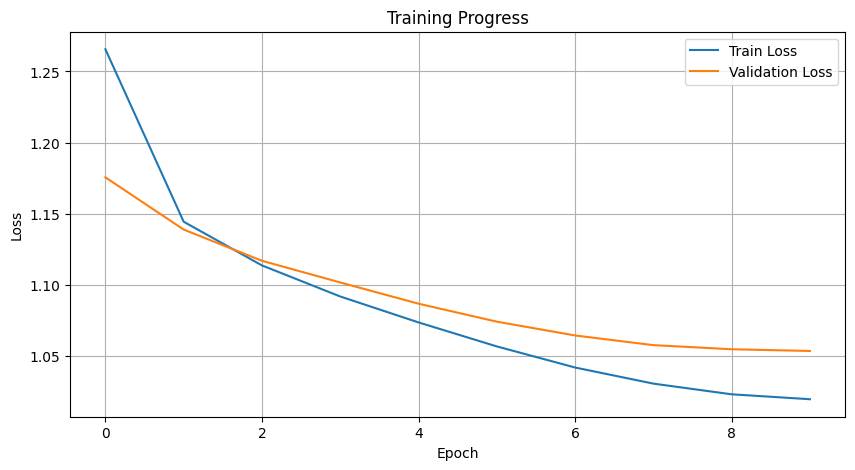

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Progress')
plt.legend()
plt.grid(True)
plt.savefig('training_progress.png')
plt.show()

Evaluation of the model on the test set


EVALUATING TEST SET (COMBINED - EFFICIENT)

Processing 39061 batches...
  Batch 0/39061 | Running Acc: 60.70% | Avg Loss: 1.2572
  Batch 100/39061 | Running Acc: 64.03% | Avg Loss: 1.1393
  Batch 200/39061 | Running Acc: 64.42% | Avg Loss: 1.1395
  Batch 300/39061 | Running Acc: 64.47% | Avg Loss: 1.1276
  Batch 400/39061 | Running Acc: 65.30% | Avg Loss: 1.0944
  Batch 500/39061 | Running Acc: 65.97% | Avg Loss: 1.0733
  Batch 600/39061 | Running Acc: 65.64% | Avg Loss: 1.0878
  Batch 700/39061 | Running Acc: 65.40% | Avg Loss: 1.0972
  Batch 800/39061 | Running Acc: 65.27% | Avg Loss: 1.1021
  Batch 900/39061 | Running Acc: 65.36% | Avg Loss: 1.1013
  Batch 1000/39061 | Running Acc: 65.29% | Avg Loss: 1.1053
  Batch 1100/39061 | Running Acc: 65.33% | Avg Loss: 1.1040
  Batch 1200/39061 | Running Acc: 65.19% | Avg Loss: 1.1081
  Batch 1300/39061 | Running Acc: 65.16% | Avg Loss: 1.1077
  Batch 1400/39061 | Running Acc: 65.14% | Avg Loss: 1.1097
  Batch 1500/39061 | Running Acc: 65.20

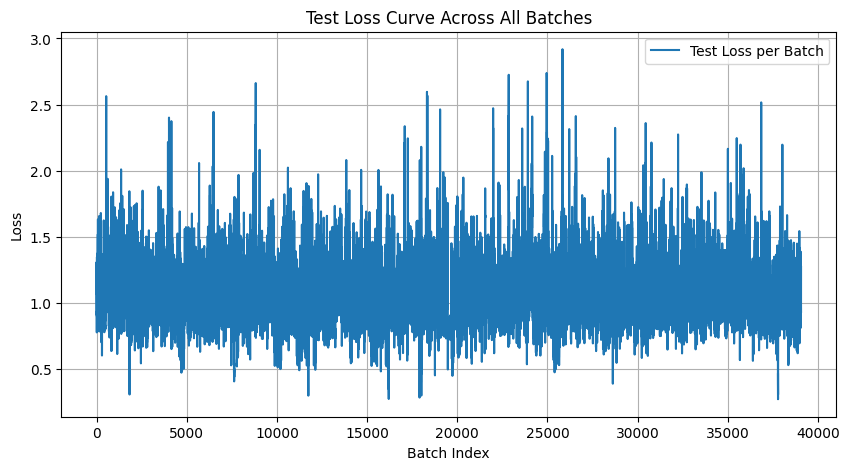


FINAL TEST RESULTS
Test Loss:        1.0720
Test Perplexity:  2.92
Test Accuracy:    66.38%
Correct/Total:    424,814,164 / 639,975,424


In [ ]:
with open("LSTM_utils/LSTM_ckpt_best.pkl", "rb") as f:
    checkpoint = pickle.load(f)

best_params = checkpoint['params']
best_cfg = checkpoint['config']

@functools.partial(jax.jit, static_argnums=(2,))
def eval_batch(params, batch, cfg):
    model = LSTM(
        hidden_size=cfg.hidden_size,
        vocab_size=cfg.vocab_size,
        num_layers=cfg.num_layers,
        dropout_rate=cfg.dropout_rate
    )

    logits = model.apply(params, batch['input'], train=False)

    logits_flat = logits.reshape(-1, cfg.vocab_size)
    targets_flat = batch['target'].reshape(-1)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits_flat, targets_flat
    ).mean()

    predictions = jnp.argmax(logits, axis=-1)
    correct = jnp.sum(predictions == batch['target'])
    total = predictions.size

    return loss, correct, total


def evaluate_test(params, test_tokens, cfg, batch_size=64):

    losses = []
    correct = 0
    total = 0

    num_batches = (len(test_tokens) - cfg.block_size - 1) // batch_size

    print(f"Processing {num_batches} batches...")

    for i in range(num_batches):
        start_idx = i * batch_size

        inputs = np.stack([
            test_tokens[start_idx + j : start_idx + j + cfg.block_size]
            for j in range(batch_size)
        ])
        targets = np.stack([
            test_tokens[start_idx + j + 1 : start_idx + j + 1 + cfg.block_size]
            for j in range(batch_size)
        ])

        batch = {
            'input': jnp.array(inputs, dtype=jnp.int32),
            'target': jnp.array(targets, dtype=jnp.int32)
        }

        batch_loss, batch_correct, batch_total = eval_batch(params, batch, cfg)

        losses.append(float(batch_loss))
        correct += int(batch_correct)
        total += int(batch_total)

        if i % 100 == 0:
            current_acc = (correct / total * 100) if total > 0 else 0
            print(f"  Batch {i}/{num_batches} | "
                  f"Running Acc: {current_acc:.2f}% | "
                  f"Avg Loss: {np.mean(losses):.4f}")

    avg_loss = np.mean(losses)
    perplexity = np.exp(avg_loss)
    accuracy = (correct / total) * 100

    return {
        'loss': avg_loss,
        'perplexity': perplexity,
        'accuracy': accuracy,
        'correct': correct,
        'total': total,
        'loss_curve': losses
    }


print("\n" + "="*70)
print("EVALUATING TEST SET (COMBINED - EFFICIENT)")
print("="*70 + "\n")

results = evaluate_test(best_params, test_text_int, best_cfg, batch_size=128)


loss_curve = results["loss_curve"]

plt.figure(figsize=(10,5))
plt.plot(loss_curve, label="Test Loss per Batch")
plt.xlabel("Batch Index")
plt.ylabel("Loss")
plt.title("Test Loss Curve Across All Batches")
plt.grid(True)
plt.legend()
plt.show()

print("\n" + "="*70)
print("FINAL TEST RESULTS")
print("="*70)
print(f"Test Loss:        {results['loss']:.4f}")
print(f"Test Perplexity:  {results['perplexity']:.2f}")
print(f"Test Accuracy:    {results['accuracy']:.2f}%")
print(f"Correct/Total:    {results['correct']:,} / {results['total']:,}")
print("="*70)